## Model Evaluation & Tuning – Part 1: Cross-Validation (CV)

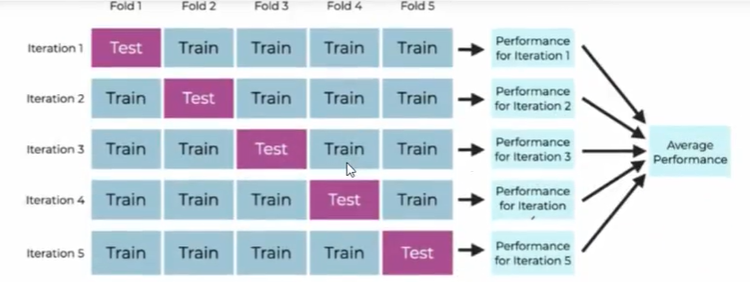

## Cross-Validation (CV)

### 1) Definition

* **Cross-Validation** is a resampling technique to estimate how well a model will generalize to unseen data.
* It repeatedly splits the dataset into training and validation "folds", trains on some folds, evaluates on the held-out fold, and averages the scores.

### 2) Concept (What, Why, How)

* **What happens in $k$-fold CV:**
* Split data into $k$ equal folds.
* For each fold $i$ ($i = 1 \dots k$): train on $k-1$ folds, validate on the held-out fold $i$.
* Collect $k$ scores $\rightarrow$ report mean $\pm$ std (optionally $95\%$ CI).

### Why it matters

* Reduces variance from a lucky/unlucky single train-test split.
* Uses data more efficiently (each sample becomes validation exactly once).
* More reliable model comparison across algorithms/hyperparameters.

### Choosing the right strategy

* **KFold:** standard tabular data with i.i.d. samples.
* **StratifiedKFold:** classification with class imbalance $\rightarrow$ keeps label ratios per fold.
* **GroupKFold:** grouped data where samples from the same group must not leak across train/val (e.g., users, patients, stores).
* **TimeSeriesSplit:** ordered/temporal data $\rightarrow$ train on the past, validate on the future (no shuffling).

### Typical $k$ values

* **Common choices:** $5$ or $10$ folds.
* Higher $k \rightarrow$ lower bias but higher variance and computation cost.
* **Leave-One-Out Cross-Validation (LOOCV)** ($k = n$): rarely needed; very computationally expensive and often high variance.

### Reporting Uncertainty

* Report **mean $\pm$ std** across folds.
* Optional rough $95\%$ Confidence Interval: $\text{mean} \pm 1.96 \times (\text{std} / \sqrt{k})$ (note that folds are not fully independent, so this CI is approximate).

---


## Common Pitfalls in Cross-Validation

* **Data leakage:** Scaling and feature selection must be performed inside the CV loop $\rightarrow$ use a Pipeline.
* **Shuffling:** For i.i.d. data, shuffle before splitting; never shuffle time series data.
* **Wrong splitter:** Don't use plain KFold for imbalanced classification or time series.
* **Using accuracy only:** Add precision, recall, F1-score, or ROC-AUC for a balanced understanding of model performance.

### 3) Intuitive Example (Analogy)

* **A student preparing for exams:** Instead of judging readiness from a single mock test (a single train-test split), the student takes $k$ different mock tests. The average performance across these tests serves as a much better estimate of true readiness.

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression

In [2]:
iris = load_iris()
x, y = iris.data, iris.target
x[: 5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [3]:
y[:5]

array([0, 0, 0, 0, 0])

In [ ]:
model = LogisticRegression(max_iter = 200, n_jobs = None) # define model: increase max_iter for convergence
# Maximum number of iterations the solver will run to converge
    # Sometimes logistic regression needs more iterations for convergence,
    # especially with scaled or high-dimensional data.

# Number of CPU cores to use for parallel processing.
    # None = use 1 core (default).
    # -1 = use all available cores for faster computation.

cv = KFold(n_splits = 5, shuffle = True, random_state = 42) # 5-fold CV with shuffling for reproducibiling
# Number of folds = 5 (data split into 5 parts) # Shuffle data before splitting (helps randomize flods)
# Seed for reproducibility (same split each run)

scores = cross_val_score(model, x, y, cv=cv, scoring = 'accuracy') # run CV  and collect accuracy

# the model we are evealuation
# features (x) and target labels (Y)
# Cross _ validation strategy (5- fold CV)
# Evaluation metrics : here we use accuracy

In [6]:
print("Fold accuracies:", scores) # show each fold's score

print("Mean accuracy:", scores.mean()) # average performance (central tendency)

print("Std dev:", scores.std()) # variability across folds

print("Approx 95% CI: [{:.3f}, {:.3f}]".format(scores.mean() - 1.96*scores.std()/np.sqrt(len(scores)),
                                               scores.mean() + 1.96*scores.std()/np.sqrt(len(scores))))
# rough CI

Fold accuracies: [1.         1.         0.93333333 0.96666667 0.96666667]
Mean accuracy: 0.9733333333333334
Std dev: 0.024944382578492935
Approx 95% CI: [0.951, 0.995]


## Note: Applying Cross-Generalization on a Real Dataset

* Now that we know about cross-validation, let's apply it on a real dataset. We'll use the Breast Cancer dataset and evaluate a Logistic Regression model.
* Instead of looking at just accuracy, we'll measure multiple metrics—precision, recall, F1, and ROC-AUC—using 10-fold stratified cross-validation. This gives us a fair and well-rounded view of how reliable the model is.

### Proper Evaluation Setup

* **Technique:** StratifiedKFold + multiple metrics + Pipeline (to avoid data leakage).
* **Dataset:** Breast Cancer (binary classification).
* **Implementation Note:** We'll scale features inside a pipeline, evaluate multiple metrics, and compute out-of-fold predictions.

In [8]:
import numpy as np

from sklearn.pipeline import Pipeline 

from sklearn.datasets import load_breast_cancer

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [9]:
data = load_breast_cancer()

x, y = data.data, data.target

x[:5]

array([[1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
        3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
        8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
        3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
        1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, 1.326e+03, 8.474e-02, 7.864e-02,
        8.690e-02, 7.017e-02, 1.812e-01, 5.667e-02, 5.435e-01, 7.339e-01,
        3.398e+00, 7.408e+01, 5.225e-03, 1.308e-02, 1.860e-02, 1.340e-02,
        1.389e-02, 3.532e-03, 2.499e+01, 2.341e+01, 1.588e+02, 1.956e+03,
        1.238e-01, 1.866e-01, 2.416e-01, 1.860e-01, 2.750e-01, 8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, 1.203e+03, 1.096e-01, 1.599e-01,
        1.974e-01, 1.279e-01, 2.069e-01, 5.999e-02, 7.456e-01, 7.869e-01,
        4.585e+00, 9.403e+01, 6.150e-03, 4.006e-02, 3.832e-02, 2.058e-02,
        2.250e-02, 4.571e-03, 2.357e

In [10]:
y[:5]

array([0, 0, 0, 0, 0])

In [15]:
# Define pipeline = preprocessing + model 

pipe = Pipeline([
    ('scalar', StandardScaler()),       # step 1: scale features (fit on train fold, apply on test fold ) 
    ('clf', LogisticRegression(max_iter=500))  # step 2 : train logistic regression classifier
])

#purpose:
# prevent data leakage( scaler is fit only on training data in each CV split)
# Keeps Workflow clean (all steps chained together)
# Makes model evaluation & hyperparameter tuning easier

## Purpose of Pipeline

* **Avoid Data Leakage**
* Normally, you would scale your features with `StandardScaler()` and then fit a model.
* But if you scale the entire dataset before cross-validation, information from the test folds "leaks" into training, leading to artificially inflated performance.
* A `Pipeline` ensures scaling is done strictly inside each CV fold by fitting the scaler on the training fold and applying it to the test fold.


* **Cleaner Workflow**
* You don't have to manually call `scaler.fit_transform(X_train)` and `scaler.transform(X_test)` every single time.
* Everything is bundled together sequentially—first scale, then classify.


* **Extensible**
* You can easily stack multiple preprocessing steps, such as imputation, encoding, and scaling, and finish with a model.

* When tuning hyperparameters with GridSearchCV, you can search across all steps in the pipeline

In [16]:
cv = StratifiedKFold(n_splits=10, shuffle = True, random_state = 42) # preserves class balance 

In [17]:
# 4) Define scoring metrics
scoring = {
    "accuracy": "accuracy",   # overall correctness
    "precision": "precision", # TP / (TP+FP)
    "recall": "recall",       # TP / (TP+FN)
    "f1": "f1",               # harmonic mean of precision & recall
    "roc_auc": "roc_auc"      # AUC of ROC curve
}

In [19]:
# run all cross-validation

cv_results = cross_validate(
    pipe, x, y, scoring = scoring, return_train_score = False
)

# Run cross - validation with 10 folds:


## What's Happening Internally

When using the cross-validation function (`cross_validate`), the process runs automatically for each fold:

* **Fit Model:** Calls `pipe.fit(X_train_fold, y_train_fold)` to train the pipeline (including feature scaling and model training) exclusively on the training portion of the fold.
* **Make Predictions:** Calls `pipe.predict(X_test_fold)` (or `pipe.predict_proba` if the evaluation metric requires probability estimates).
* **Collect Metrics:** Evaluates and collects the performance metrics for that specific fold.
* **Repeat:** Iterates the training and evaluation steps across all $k$ folds.
* **Return Results:** Returns a dictionary containing the collected metrics across all folds.

---

### StratifiedKFold Demo ($3$ Folds)

In [20]:
# 6) Display results (mean ± std)
for metric in scoring.keys():
    values = cv_results[f"test_{metric}"]
    print(f"{metric:>9}: {values.mean():.3f} ± {values.std():.3f}")

 accuracy: 0.981 ± 0.007
precision: 0.978 ± 0.014
   recall: 0.992 ± 0.007
       f1: 0.985 ± 0.005
  roc_auc: 0.995 ± 0.004


## Observation

* Our $10$-fold cross-validation results show very strong and stable performance.
* Accuracy is about $97.5\% \pm 2\%$, meaning across folds the model is consistently correct on most patients.
* Precision is $\sim97.4\%$ — so when the model predicts cancer, it's right about $97\%$ of the time.
* Recall is even higher at $\sim98.9\%$ — the model successfully detects almost all actual cancer cases, which is critical in healthcare.
* The F1-score ($98.1\%$ ) balances precision and recall, confirming overall robustness.
* Finally, ROC-AUC is $\sim0.995$ — nearly perfect separation between patients with and without cancer.
* The low standard deviations (small $\pm$ values) show that the model performs consistently across all folds, not just on one lucky split.

---


## Model Evaluation & Tuning – Part 2: GridSearchCV

### 1) Definition

* **GridSearchCV** is a hyperparameter tuning technique that systematically searches over a grid of parameters for a given model.
* It uses cross-validation for each parameter combination.
* The best combination is selected based on performance metrics.

### 2) Concept (What, Why, How)

* **What happens in GridSearchCV:**
* You define a model and a grid of hyperparameters.
* For each parameter combination:
* Train and validate the model using cross-validation.
* Record the average performance.


* Select the best parameters with the highest CV score.

## Why it matters

* Hyperparameters (like learning rate, tree depth, regularization strength) strongly influence model performance.
* Manual tuning is trial-and-error and prone to bias.
* GridSearchCV provides a systematic, reproducible way to optimize models.

## Key points

* `scoring` = choose the metric to optimize (accuracy, recall, f1, ROC-AUC, RMSE).
* `cv` = CV strategy (KFold, StratifiedKFold, TimeSeriesSplit).
* `refit=True` = after finding best parameters, retrain model on full dataset.

* Computationally expensive if the grid is large $\rightarrow$ can use `RandomizedSearchCV` as an alternative.

### 3) Intuitive Example (Analogy)

* **Baking analogy:**
* **Baking analogy:**
* You test different oven temperatures, sugar amounts, and baking times.
* For each combination, you taste-test multiple cakes (cross-validation).
* You pick the recipe that gives the most consistent, best taste.




In [21]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [22]:
# load dataset 

iris = load_iris()

x, y = iris.data, iris.target

x[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [23]:
y[:5]

array([0, 0, 0, 0, 0])

In [24]:
# Pipeline: scaling + classifier
pipe = Pipeline([
    ("scaler", StandardScaler()), # scale features safely inside CV
    ("clf", LogisticRegression(max_iter=500))
])

# Pipeline = chain preprocessing + model together
# Step 1: Standardize features (fit on train folds, apply to test folds)
# Step 2: Apply Logistic Regression classifier
# Benefit: prevents data leakage and keeps workflow clean


In [29]:
# Define hyperparameter grid
param_grid = {
    "clf__penalty": ["l1", "l2"],       # type of regularization
    "clf__C": [0.01, 0.1, 1, 10],      # regularization strength
    "clf__solver": ["saga"]       # solver that supports l1/l2
}

# Define hyperparameter grid for Logistic Regression

# "clf__penalty": Regularization type (controls how coefficients are penalized)
#   - "l1": Lasso-style (forces some coefficients to zero $\rightarrow$ feature selection)
#   - "l2": Ridge-style (shrinks coefficients smoothly $\rightarrow$ keeps all features)

# "clf__C": Inverse of regularization strength (smaller C = stronger regularization)
#   - 0.01: very strong penalty -> simpler model
#   - 0.1: moderate penalty
#   - 1: default strength
#   - 10: weaker penalty -> more complex model

# "clf__solver": Algorithm used for optimization
#   - "saga": The saga solver supports both l1 and l2 penalties natively for multi-class classification., good for small to medium datasets

In [31]:
# GridSearchCV setup
grid = GridSearchCV(
    estimator=pipe,        # The pipeline (scaling + model) we want to tune
                           # GridSearchCV will call fit() and predict() internally for each parameter set
    
    param_grid=param_grid, # Dictionary of hyperparameters to try (all combinations will be evaluated)
    
    cv=5,                  # 5-fold cross-validation for each parameter set
                           # ensures performance is reliable, not from a lucky split
    
    scoring="accuracy",    # Metric to evaluate models (here: accuracy)
                           # can also use 'f1', 'recall', 'roc_auc' depending on the problem
    
    refit=True,            # After finding the best parameters, refit the model on the full dataset
                           # so we get the final best model ready for prediction
    
    n_jobs=-1              # Use all available CPU cores for faster computation
)

In [32]:
# Run the grid search

grid.fit(x,y)
# After fitting, GridSearchCV has:
# - searched all parameter combinations
# - run cross-validation for each
# - selected the best-performing set of hyperparameters

# Print best parameters found across all CV folds
print("Best Parameters:", grid.best_params_)

# Print best average CV score achieved with those parameters
print("Best Cross-Validation Accuracy:", grid.best_score_)

# Evaluate the final best model on the full dataset
# (porque refit=True retrained the best model on all data)
print("Test Accuracy with Best Model:", grid.score(x, y))

Best Parameters: {'clf__C': 10, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Best Cross-Validation Accuracy: 0.9733333333333334
Test Accuracy with Best Model: 0.98


c:\Users\skuch\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\skuch\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\skuch\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Takeaway

* Cross-Validation helps us evaluate models, and GridSearchCV builds on that to *tune* them.
* Together, they are essential tools for building reliable, high-performing machine learning models.

## Cross-Validation vs. GridSearchCV Comparison

| Aspect | Cross-Validation (Part 1) | GridSearchCV (Part 2) |
| --- | --- | --- |
| **Purpose** | Evaluate model performance reliably | Tune model hyperparameters systematically |
| **What it does** | Splits dataset into $k$ folds, trains on $k-1$, tests on $1$, repeats | Tries all parameter combinations, uses CV for each, finds best |
| **Output** | Mean $\pm$ std of chosen metric (accuracy, recall, etc.) | Best hyperparameter set + best CV score |
| **Focus** | Generalization ability | Optimization of parameters |
| **When to use** | Anytime you want robust evaluation | When model performance depends heavily on hyperparameters |
| **Example** | Logistic Regression evaluated with 10-fold CV | Random Forest tuned with 81 parameter combinations |

---
